# 04 — Discussion figures and tables

Produces the Discussion-section figures:

| Output | Generator |
|---|---|
| Fig 10 — Robustness of inter-site contrast | `make_results_figures.fig_robustness` |
| Fig 11 — alpha-sweep (Martinez per-site density retrieval) | `make_alpha_sweep_figure.main` |
| Table 4 — Pooled-fit model comparison | inlined below |

Wall time: 5-10 min.

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts' / 'figures'))
OUTPUT = ROOT / 'output'
FIGS = ROOT / 'paper' / 'letter' / 'figures'

d = json.loads((OUTPUT / 'kd_retrieval_results.json').read_text())

from IPython.display import Image, display
import io
def show_fig(name):
    """Display a figure inline. Prefers the PNG companion; falls back to
    rendering the PDF on the fly via pymupdf if no PNG exists."""
    stem = name.replace('.pdf','').replace('.png','')
    png = FIGS / f"{stem}.png"
    if png.exists():
        display(Image(filename=str(png))); return
    pdf = FIGS / f"{stem}.pdf"
    if pdf.exists():
        try:
            import fitz
            pix = fitz.open(str(pdf))[0].get_pixmap(dpi=140)
            display(Image(data=pix.tobytes("png")))
        except Exception as e:
            print(f"  (couldn't render {pdf.name}: {e})")
    else:
        print(f"(no figure file for {stem})")


## Fig 10 — Robustness of the inter-site contrast

Panel (a) maps the K_d/Q_b degeneracy with a TwoSlopeNorm diverging
colormap. Panels (b),(c) show the joint (K_d, H) RMSE surface.

  → /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/paper/letter/figures/fig_robustness.pdf


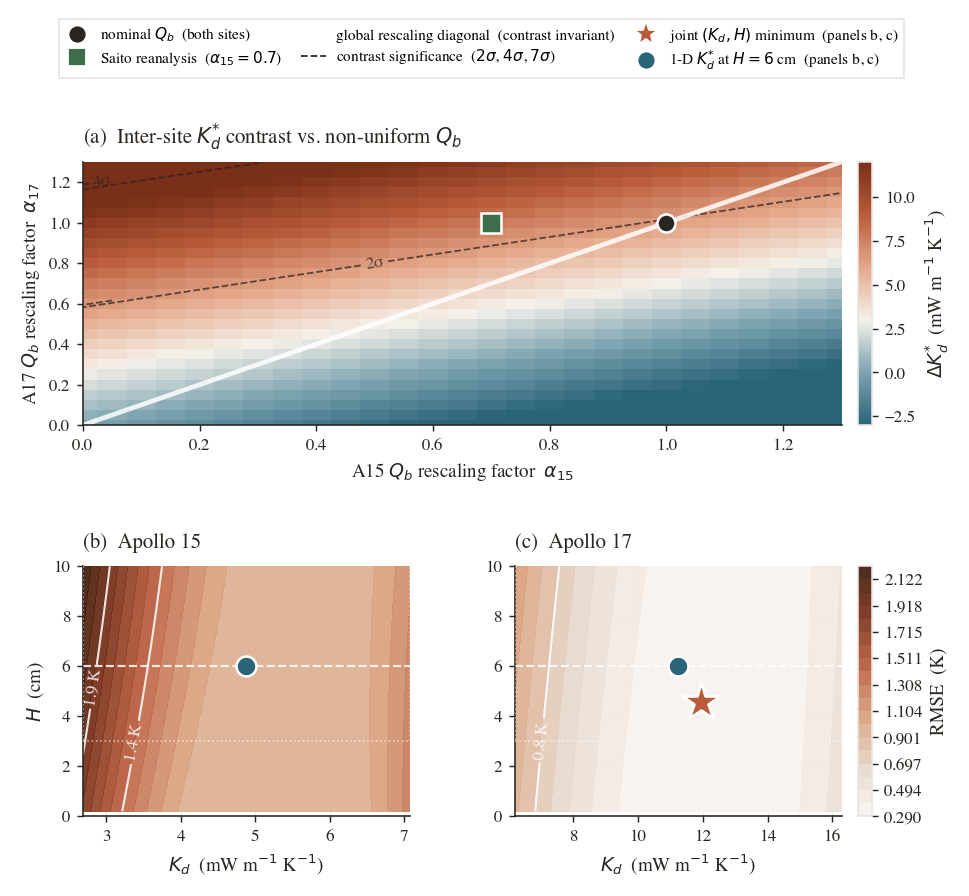

In [2]:
from make_results_figures import fig_robustness
fig_robustness(d, FIGS / 'fig_robustness.pdf')
show_fig('fig_robustness')

## Fig 11 — alpha-sweep (Martinez per-site density retrieval)

Grants the published Martinez K(T,rho) form one per-site lever — the
deep bulk density rho_d via alpha = rho_d / 1800. Sweeps alpha against
the deep-sensor RMSE at each site.

  -> /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/paper/letter/figures/fig_alpha_sweep.pdf


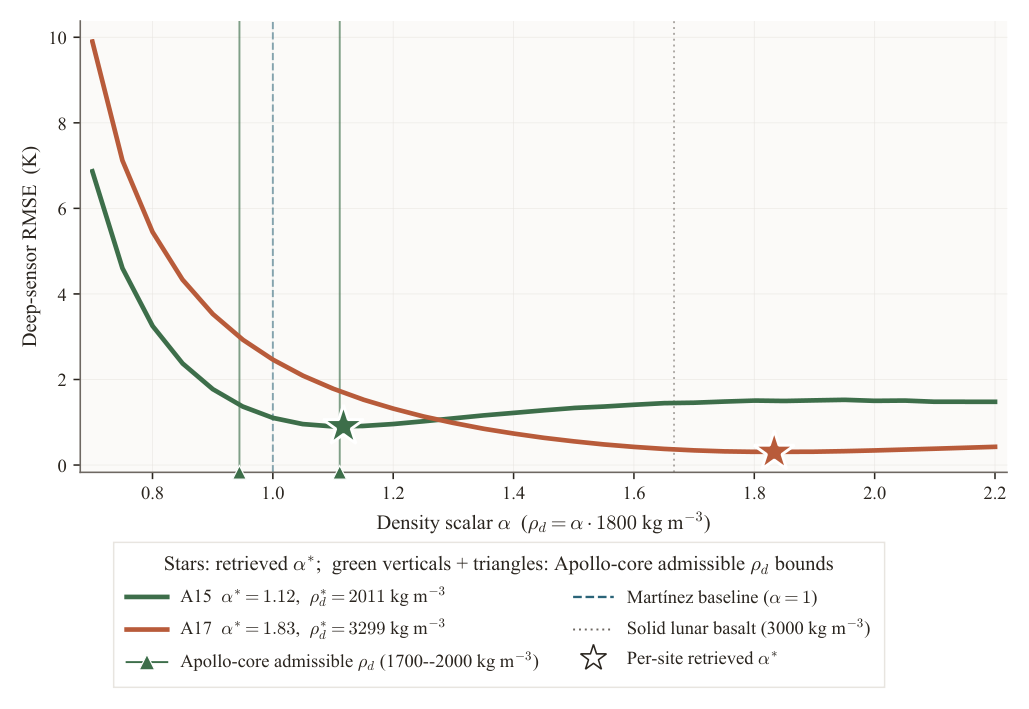

In [3]:
import make_alpha_sweep_figure
make_alpha_sweep_figure.main()
show_fig('fig_alpha_sweep')

## Table 4 — Pooled-fit model comparison

AICc comparison of three nested models: M1 (per-site K_d, Q_b fixed),
M2 (uniform K_d, Q_b free per site), M3 (uniform K_d, Q_b fixed per
site). The DeltaAICc ~ 5 favoring M1 is what supports reading the
inter-site difference as a conductivity contrast rather than a
basal-flux contrast.

In [4]:
import pandas as pd
t4 = json.loads((OUTPUT / 'model_selection.json').read_text())
rows = []
for site, models in t4.items():
    for model_name, m in models.items():
        rows.append({'Site': site, 'Model': model_name,
                     'N': m['n'], 'RMSE (K)': round(m['rmse'], 2),
                     'chi2': round(m['chi2'], 1), 'AICc': round(m['aicc'], 2)})
pd.DataFrame(rows)

,Site,Model,N,RMSE (K),chi2,AICc
0,A15,hayne_global,7,1.37,4573.6,7.26
1,A15,hayne_fit,7,0.90,1894.7,5.54
2,A15,layer3_fit,7,0.90,1911.8,5.58
3,A17,hayne_global,16,2.96,161197.0,37.05
4,A17,hayne_fit,16,0.30,1059.1,-33.48
5,A17,layer3_fit,16,0.40,1995.2,-24.26


## Final sanity check — all paper figures present

In [5]:
expected = [
    'fig_intro_probe.pdf',
    'fig_context_map.pdf',
    'fig_apollo_timeline.pdf',
    'fig_amplitude_vs_depth.pdf',
    'fig_apollo_mean_T_profile.pdf',
    'fig_kd_sweep.pdf',
    'fig_bootstrap.pdf',
    'fig_thermal_profiles.pdf',
    'fig_diviner_closure.pdf',
    'fig_robustness.pdf',
    'fig_alpha_sweep.pdf',
]
missing = [f for f in expected if not (FIGS / f).exists()]
if missing:
    print('MISSING figures:')
    for f in missing:
        print('   ', f)
else:
    print('All 11 paper figures present in paper/letter/figures/')
    print()
    print('Now compile the manuscript:')
    print('    cd paper/letter && latexmk -pdf letter.tex')

All 11 paper figures present in paper/letter/figures/

Now compile the manuscript:
    cd paper/letter && latexmk -pdf letter.tex
